Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.3612 - loss: 1.7625 - val_accuracy: 0.5588 - val_loss: 1.2801
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.5272 - loss: 1.3398 - val_accuracy: 0.5967 - val_loss: 1.1677
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.5685 - loss: 1.2217 - val_accuracy: 0.6203 - val_loss: 1.0902
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.5973 - loss: 1.1556 - val_accuracy: 0.6250 - val_loss: 1.0673
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6081 - loss: 1.1156 - val_accuracy: 0.6536 - val_loss: 1.0203
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.6237 - loss: 1.0812 - val_accuracy: 0.6667 - val_loss: 0.9641
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.6312 - loss: 1.0573 - val_accuracy: 0.6772 - val_loss: 0.9340
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.6408 -

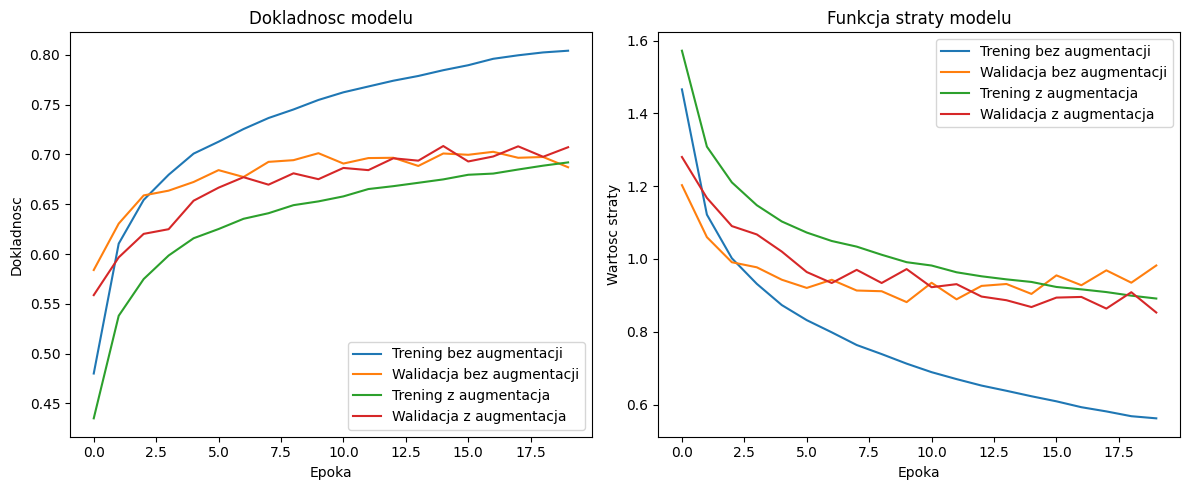

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# One-hot encode the labels
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

# Normalize the images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Define a function to create the model
def create_model():
    return keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])

# Create an ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Fit the generator to the training data
datagen.fit(x_train)

# Create and compile the model with augmentation
model_aug = create_model()
model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model with augmentation
history_aug = model_aug.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

# Create and compile the model without augmentation
model_no_aug = create_model()
model_no_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model without augmentation
history_no_aug = model_no_aug.fit(
    x_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_no_aug.history['accuracy'], label='Trening bez augmentacji')
plt.plot(history_no_aug.history['val_accuracy'], label='Walidacja bez augmentacji')
plt.plot(history_aug.history['accuracy'], label='Trening z augmentacja')
plt.plot(history_aug.history['val_accuracy'], label='Walidacja z augmentacja')
plt.title('Dokladnosc modelu')
plt.xlabel('Epoka')
plt.ylabel('Dokladnosc')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_no_aug.history['loss'], label='Trening bez augmentacji')
plt.plot(history_no_aug.history['val_loss'], label='Walidacja bez augmentacji')
plt.plot(history_aug.history['loss'], label='Trening z augmentacja')
plt.plot(history_aug.history['val_loss'], label='Walidacja z augmentacja')
plt.title('Funkcja straty modelu')
plt.xlabel('Epoka')
plt.ylabel('Wartosc straty')
plt.legend()

plt.tight_layout()
plt.show()


✓ Zadanie 1. Jaka metryka została zastosowana w modelu? Jakie jest zadanie metryki?
Metryka zastosowana w modelu:accuracy
Metryka accuracy mierzy odsetek poprawnie sklasyfikowanych przykładów względem wszystkich przykładów.

✓ Zadanie 2. Przeanalizuj otrzymane wykresy? Jaki efekt powoduje zastosowanie augumentacji? Zwróć szczególną uwagę na przebieg krzywej walidacyjnej względem odpowiadającej jej krzywej treningowej.
Model bez augmentacji: model przeucza się (overfitting) — uczy się za dobrze danych treningowych, ale traci zdolność generalizacji.

Model z augmentacją:
zastosowanie augmentacji zmniejsza przeuczenie — model lepiej generalizuje na nieznane dane.


In [ ]:
print("\nWyniki końcowe:")

loss_no_aug, accuracy_no_aug = model_no_aug.evaluate(x_test, y_test, verbose=0)
print(f"Model bez augmentacji - Dokładność na zbiorze testowym: {accuracy_no_aug:.4f}, Strata: {loss_no_aug:.4f}")

loss_aug, accuracy_aug = model_aug.evaluate(x_test, y_test, verbose=0)
print(f"Model z augmentacją - Dokładność na zbiorze testowym: {accuracy_aug:.4f}, Strata: {loss_aug:.4f}")



Wyniki końcowe:
Model bez augmentacji - Dokładność na zbiorze testowym: 0.6872, Strata: 0.9821
Model z augmentacją - Dokładność na zbiorze testowym: 0.7073, Strata: 0.8529


✓ Zadanie 3. Dlaczego, pomimo zastosowania augmentacji danych podczas treningu sieci neuronowej na zbiorze CIFAR-10, końcowa dokładność klasyfikacji na niezmienianym zbiorze testowym nie wykazuje znaczącej poprawy w porównaniu do modelu trenowanego bez augmentacji? Jakie czynniki mogły wpłynąć na ten rezultat? Czy są jakieś korzyści wynikające z augmentacji niekoniecznie manifestujące się jedynie w ostatecznej metryce dokładności? Zwiększ liczbę epok uczących w modelu do 30 i ponów obliczenia oraz zapisz wnioski z uzyskanej dokładności modelu.

In [ ]:

history_aug = model_aug.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(x_test, y_test),
    verbose=1
)


history_no_aug = model_no_aug.fit(
    x_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(x_test, y_test),
    verbose=1
)

# Wyniki końcowe
print("\nWyniki końcowe (30 epok):")

loss_no_aug, accuracy_no_aug = model_no_aug.evaluate(x_test, y_test, verbose=0)
print(f"Model bez augmentacji - Dokładność na zbiorze testowym: {accuracy_no_aug:.4f}, Strata: {loss_no_aug:.4f}")

loss_aug, accuracy_aug = model_aug.evaluate(x_test, y_test, verbose=0)
print(f"Model z augmentacją - Dokładność na zbiorze testowym: {accuracy_aug:.4f}, Strata: {loss_aug:.4f}")


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6955 - loss: 0.8877 - val_accuracy: 0.7089 - val_loss: 0.8721
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.6981 - loss: 0.8745 - val_accuracy: 0.7267 - val_loss: 0.8094
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7023 - loss: 0.8597 - val_accuracy: 0.7243 - val_loss: 0.8054
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.7008 - loss: 0.8687 - val_accuracy: 0.7231 - val_loss: 0.8234
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 52ms/step - accuracy: 0.7021 - loss: 0.8627 - val_accuracy: 0.7148 - val_loss: 0.8475
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.7035 - loss: 0.8543 - val_accuracy: 0.7158 - val_loss: 0.8442
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.7046 - loss: 0.8458 - val_accuracy: 0.7197 - val_loss: 0.8459
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.7088 -